# EDA: Exploratory Data Analysis

## Importing needed libraries

In [262]:
import pandas as pd
import numpy as np

## Reading the dataset

In [263]:
# df_org = pd.read_csv("/content/Customer-Churn-Records.csv")
df_org = pd.read_csv("/content/bank_data_with_NaN.csv")

print(df_org.shape)

df_org.head()

(10000, 13)


,id,last_name,credit_score,country,gender,age,years_customer,balance_euros,num_products,has_credit_card,is_active,salary_euros,retained
0,15634602.0,Hargrave,619.0,Switzerland,f,42.0,2.0,0.00,1.0,1.0,1.0,101348.88,0.0
1,15647311.0,Hill,608.0,Austria,f,41.0,1.0,83807.86,1.0,0.0,1.0,112542.58,1.0
2,15619304.0,Onio,502.0,Switzerland,f,42.0,8.0,159660.80,3.0,1.0,0.0,113931.57,0.0
3,15701354.0,Boni,699.0,Switzerland,f,39.0,1.0,0.00,2.0,0.0,0.0,93826.63,1.0
4,15737888.0,Mitchell,850.0,Austria,f,43.0,2.0,125510.82,1.0,1.0,1.0,79084.10,1.0


In [264]:
df_org.columns.tolist()

['id',
 'last_name',
 'credit_score',
 'country',
 'gender',
 'age',
 'years_customer',
 'balance_euros',
 'num_products',
 'has_credit_card',
 'is_active',
 'salary_euros',
 'retained']

## Data Quality Check

### 1. Check for Null Values (NaN, Null, None)

In [265]:
df_org.isna().sum()


,0
id,102
last_name,76
credit_score,69
country,80
gender,73
age,79
years_customer,85
balance_euros,77
num_products,64
has_credit_card,73


### 2. Dealing with Null Values

#### 2-1. Drop all nulls

In [266]:
df = df_org.copy()

df.dropna(inplace=True)

In [267]:
df.isna().sum()

,0
id,0
last_name,0
credit_score,0
country,0
gender,0
age,0
years_customer,0
balance_euros,0
num_products,0
has_credit_card,0


In [268]:
df.shape

(9047, 13)

#### 2-2. Fill all null values with a single value

In [269]:
df = df_org.copy()

df.fillna(0, inplace=True)

print(df.shape)
df.isna().sum()

(10000, 13)


,0
id,0
last_name,0
credit_score,0
country,0
gender,0
age,0
years_customer,0
balance_euros,0
num_products,0
has_credit_card,0


#### 2-3. Column-wise data cleaning

In [275]:
df = df_org.copy()

df.drop(["id", "last_name"], axis=1, inplace=True)

df.loc[df['country'].isna(), 'country'] = np.random.choice(df['country'].dropna())
df.loc[df['gender'].isna(), 'gender'] = np.random.choice(df['gender'].dropna())
df.loc[df['years_customer'].isna(), 'years_customer'] = np.random.choice(df['years_customer'].dropna())
df.loc[df['num_products'].isna(), 'num_products'] = np.random.choice(df['num_products'].dropna())
df.loc[df['has_credit_card'].isna(), 'has_credit_card'] = np.random.choice(df['has_credit_card'].dropna())
df.loc[df['is_active'].isna(), 'is_active'] = np.random.choice(df['is_active'].dropna())

df["credit_score"] = df["credit_score"].fillna(round(df["credit_score"].median()))
df["age"] = df["age"].fillna(round(df["age"].median()))
df["balance_euros"] = df["balance_euros"].fillna(round(df["balance_euros"].median()))
df["salary_euros"] = df["salary_euros"].fillna(round(df["salary_euros"].mean()))

print("After Data Cleansing:")
df.isna().sum()


After Data Cleansing:


,0
credit_score,0
country,0
gender,0
age,0
years_customer,0
balance_euros,0
num_products,0
has_credit_card,0
is_active,0
salary_euros,0


<Axes: >

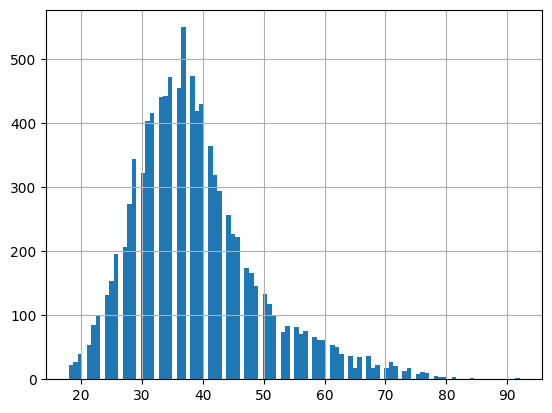

In [277]:
df["age"].hist(bins=100)